# Leduc Hold'em

Leduc Hold'em es una versión pequeña de poker de información imperfecta. Tiene 2 jugadores y un mazo chico con pares de cartas `J`, `Q` y `K`. Cada jugador recibe una carta privada; luego hay una primera ronda de apuestas, se revela una carta pública y hay una segunda ronda de apuestas.

Al final gana quien tenga la mejor mano: si la carta privada coincide con la carta pública, forma par y supera a cualquier carta alta; si nadie tiene par, gana la carta privada más alta. Como en poker real, un jugador también puede ganar antes si el rival foldea.

Esta notebook usa el wrapper `Leduc` provisto en `games/leduc.py`, basado en `pettingzoo.classic.leduc_holdem_v4`.

**Nota sobre ISMCTS:** en Kuhn, ISMCTS usa `random_change()` para muestrear cartas ocultas alternativas del rival durante cada simulación. En Leduc ese método todavía no está implementado, así que ISMCTS cae en `clone()` y repite siempre el mismo mundo oculto (mismas cartas privadas y pública). Eso no invalida CFR ni el uso de acciones legales vía `available_actions()`, pero sí hace que ISMCTS sea un baseline exploratorio: puede subestimar incertidumbre, converger peor que en Kuhn y dar ventaja artificial a estrategias que explotan un único escenario oculto fijo.

In [1]:
from pathlib import Path
import sys
import importlib.util
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt

CFR_DIR = Path.cwd() if Path.cwd().name == 'cfr' else Path.cwd() / 'cfr'
PROJECT_ROOT = CFR_DIR.parent
for path in [str(PROJECT_ROOT), str(CFR_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from games.leduc import Leduc
from agents.counterfactualregret import CounterFactualRegret


def load_class(module_path, class_name):
    spec = importlib.util.spec_from_file_location(class_name, module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return getattr(module, class_name)


InformationSetMCTS = load_class(PROJECT_ROOT / 'agents' / 'ismcts.py', 'InformationSetMCTS')
RandomAgent = load_class(PROJECT_ROOT / 'agents' / 'agent_random.py', 'RandomAgent')

## Ejemplo de una partida

En el wrapper, las acciones disponibles dependen del estado. La codificación heredada del entorno es: `0 = call`, `1 = raise`, `2 = fold`, `3 = check`. La lista `available_actions()` indica cuáles son legales en cada turno.

In [2]:
game = Leduc(render_mode='')
game.reset()

while not game.game_over():
    agent = game.agent_selection
    actions = game.available_actions()
    action = np.random.choice(actions)
    print(f'{agent} obs={game.observe(agent)} actions={actions} -> action={action}')
    game.step(action)

print('Rewards:', game.rewards)

player_0 obs=J_#_1_2_0 actions=[0, 1, 2] -> action=0
player_1 obs=J_#_2_2_0c actions=[1, 2, 3] -> action=2
Rewards: {'player_0': np.float64(1.0), 'player_1': np.float64(-1.0)}


## Comparación de agentes

Comparamos `CFR`, `ISMCTS` y `Random`. `CFR` es el método más natural para información imperfecta. Con pocas iteraciones puede no haber visitado todos los infosets de Leduc, así que estos resultados son exploratorios.

Leduc Hold'em es un benchmark pequeño de poker y su equilibrio de Nash puede aproximarse con algoritmos como CFR, pero en esta notebook no cargamos una solución analítica ni una estrategia óptima externa como referencia. Por eso la comparación se justifica por reward promedio, tiempos de entrenamiento/evaluación y comportamiento relativo entre agentes; no debe leerse como prueba de haber alcanzado equilibrio.

`ISMCTS` se incluye como baseline de búsqueda online; en este wrapper de Leduc todavía no hay una determinización específica como en Kuhn, por lo que debe interpretarse con cautela.

In [3]:
def bind_agents_to_game(agents, game):
    for agent in game.agents:
        agents[agent].game = game


def play_game(game, agents):
    bind_agents_to_game(agents, game)
    game.reset()
    while not game.game_over():
        action = agents[game.agent_selection].action()
        if action not in game.available_actions():
            action = np.random.choice(game.available_actions())
        game.step(action)
    return game.rewards.copy()


def build_agent(kind, game, agent, cfr_niter=100, ismcts_simulations=50, ismcts_rollouts=1):
    if kind == 'cfr':
        player = CounterFactualRegret(game=game, agent=agent)
        player.train(cfr_niter)
        return player
    if kind == 'ismcts':
        return InformationSetMCTS(
            game=game,
            agent=agent,
            simulations=ismcts_simulations,
            rollouts=ismcts_rollouts,
        )
    if kind == 'random':
        return RandomAgent(game=game, agent=agent)
    raise ValueError(f'Unknown agent kind: {kind}')


def evaluate_match(
    kind_agent_0,
    kind_agent_1,
    n_games=500,
    cfr_niter=100,
    ismcts_simulations=50,
    ismcts_rollouts=1,
    seed=None,
):
    train_game = Leduc(render_mode='', seed=seed)
    train_game.reset()
    start = perf_counter()
    agents = {
        train_game.agents[0]: build_agent(kind_agent_0, train_game, train_game.agents[0], cfr_niter, ismcts_simulations, ismcts_rollouts),
        train_game.agents[1]: build_agent(kind_agent_1, train_game, train_game.agents[1], cfr_niter, ismcts_simulations, ismcts_rollouts),
    }
    setup_time = perf_counter() - start

    eval_game = Leduc(render_mode='', seed=seed)
    cum_rewards = {agent: 0.0 for agent in eval_game.agents}
    wins = {agent: 0 for agent in eval_game.agents}

    start = perf_counter()
    for _ in range(n_games):
        rewards = play_game(eval_game, agents)
        for agent, reward in rewards.items():
            cum_rewards[agent] += reward
        winner = max(rewards, key=rewards.get)
        wins[winner] += 1
    eval_time = perf_counter() - start

    return {
        'agent_0_kind': kind_agent_0,
        'agent_1_kind': kind_agent_1,
        'agent_0_value': cum_rewards[eval_game.agents[0]] / n_games,
        'agent_1_value': cum_rewards[eval_game.agents[1]] / n_games,
        'wins': wins,
        'setup_time': setup_time,
        'eval_time': eval_time,
    }

In [4]:
matchups = [
    ('cfr', 'cfr'),
    ('cfr', 'ismcts'),
    ('ismcts', 'cfr'),
    ('ismcts', 'ismcts'),
    ('cfr', 'random'),
    ('random', 'cfr'),
    ('ismcts', 'random'),
    ('random', 'ismcts'),
    ('random', 'random'),
]

results = []
for kind_0, kind_1 in matchups:
    result = evaluate_match(
        kind_agent_0=kind_0,
        kind_agent_1=kind_1,
        n_games=500,
        cfr_niter=100,
        ismcts_simulations=50,
        ismcts_rollouts=1,
        seed=None,
    )
    results.append(result)
    print(
        f"{kind_0:>6} vs {kind_1:<6} | "
        f"value agent_0={result['agent_0_value']:.3f} | "
        f"value agent_1={result['agent_1_value']:.3f} | "
        f"wins={result['wins']} | "
        f"setup={result['setup_time']:.2f}s | eval={result['eval_time']:.2f}s"
    )

   cfr vs cfr    | value agent_0=-0.115 | value agent_1=0.115 | wins={'player_0': 223, 'player_1': 277} | setup=52.45s | eval=0.33s
   cfr vs ismcts | value agent_0=-0.919 | value agent_1=0.919 | wins={'player_0': 217, 'player_1': 283} | setup=26.39s | eval=213.82s
ismcts vs cfr    | value agent_0=0.883 | value agent_1=-0.883 | wins={'player_0': 357, 'player_1': 143} | setup=28.20s | eval=179.45s
ismcts vs ismcts | value agent_0=0.058 | value agent_1=-0.058 | wins={'player_0': 305, 'player_1': 195} | setup=0.00s | eval=417.45s
   cfr vs random | value agent_0=0.286 | value agent_1=-0.286 | wins={'player_0': 299, 'player_1': 201} | setup=38.95s | eval=0.45s
random vs cfr    | value agent_0=-0.139 | value agent_1=0.139 | wins={'player_0': 228, 'player_1': 272} | setup=39.19s | eval=0.45s
ismcts vs random | value agent_0=0.827 | value agent_1=-0.827 | wins={'player_0': 337, 'player_1': 163} | setup=0.00s | eval=254.60s
random vs ismcts | value agent_0=-0.958 | value agent_1=0.958 | wins={

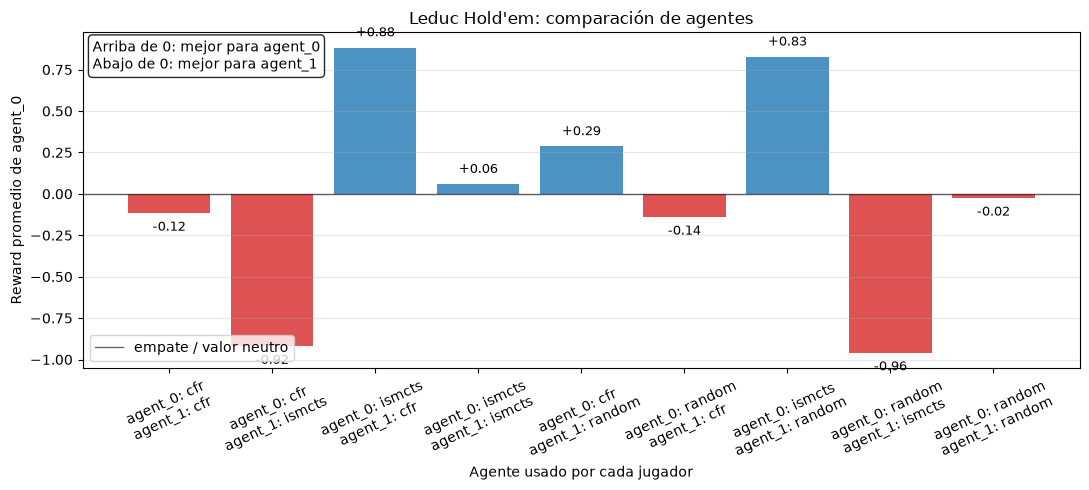

Interpretación: valores positivos favorecen a agent_0 y negativos favorecen a agent_1. El mejor resultado para agent_0 es ismcts vs cfr (+0.88); el peor es random vs ismcts (-0.96).


In [5]:
labels = [f"agent_0: {r['agent_0_kind']}\nagent_1: {r['agent_1_kind']}" for r in results]
values = [r['agent_0_value'] for r in results]

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['tab:blue' if value >= 0 else 'tab:red' for value in values]
bars = ax.bar(labels, values, color=colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=1, alpha=0.6, label='empate / valor neutro')

for bar, value in zip(bars, values):
    offset = 0.05 if value >= 0 else -0.05
    va = 'bottom' if value >= 0 else 'top'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f'{value:+.2f}',
        ha='center',
        va=va,
        fontsize=9,
    )

ax.text(
    0.01,
    0.98,
    'Arriba de 0: mejor para agent_0\nAbajo de 0: mejor para agent_1',
    transform=ax.transAxes,
    va='top',
    bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85},
)
ax.set_title("Leduc Hold'em: comparación de agentes")
ax.set_ylabel('Reward promedio de agent_0')
ax.set_xlabel('Agente usado por cada jugador')
ax.tick_params(axis='x', rotation=25)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

best = max(results, key=lambda r: r['agent_0_value'])
worst = min(results, key=lambda r: r['agent_0_value'])
print(
    'Interpretación: valores positivos favorecen a agent_0 y negativos favorecen a agent_1. '
    f"El mejor resultado para agent_0 es {best['agent_0_kind']} vs {best['agent_1_kind']} "
    f"({best['agent_0_value']:+.2f}); el peor es {worst['agent_0_kind']} vs {worst['agent_1_kind']} "
    f"({worst['agent_0_value']:+.2f})."
)

## Convergencia de CFR

A diferencia de Kuhn Poker, Leduc no tiene una solución analítica conocida como referencia directa. Sin embargo, podemos observar cómo converge el reward promedio de CFR a medida que aumentan las iteraciones de entrenamiento. En un equilibrio de Nash de suma cero, ambos agentes deberían obtener rewards que sumen cero; si el juego es simétrico, ambos se acercan a 0.

Entrenando CFR con diferentes iteraciones para observar convergencia...

Entrenando con 50 iteraciones...
  agent_0=-0.1090  agent_1=+0.1090  suma=+0.0000  t=40.75s
Entrenando con 200 iteraciones...
  agent_0=-0.0795  agent_1=+0.0795  suma=+0.0000  t=159.65s
Entrenando con 500 iteraciones...
  agent_0=-0.1905  agent_1=+0.1905  suma=+0.0000  t=395.07s
Entrenando con 1,000 iteraciones...
  agent_0=+0.0285  agent_1=-0.0285  suma=+0.0000  t=807.98s
Entrenando con 2,000 iteraciones...
  agent_0=+0.0550  agent_1=-0.0550  suma=+0.0000  t=1733.46s


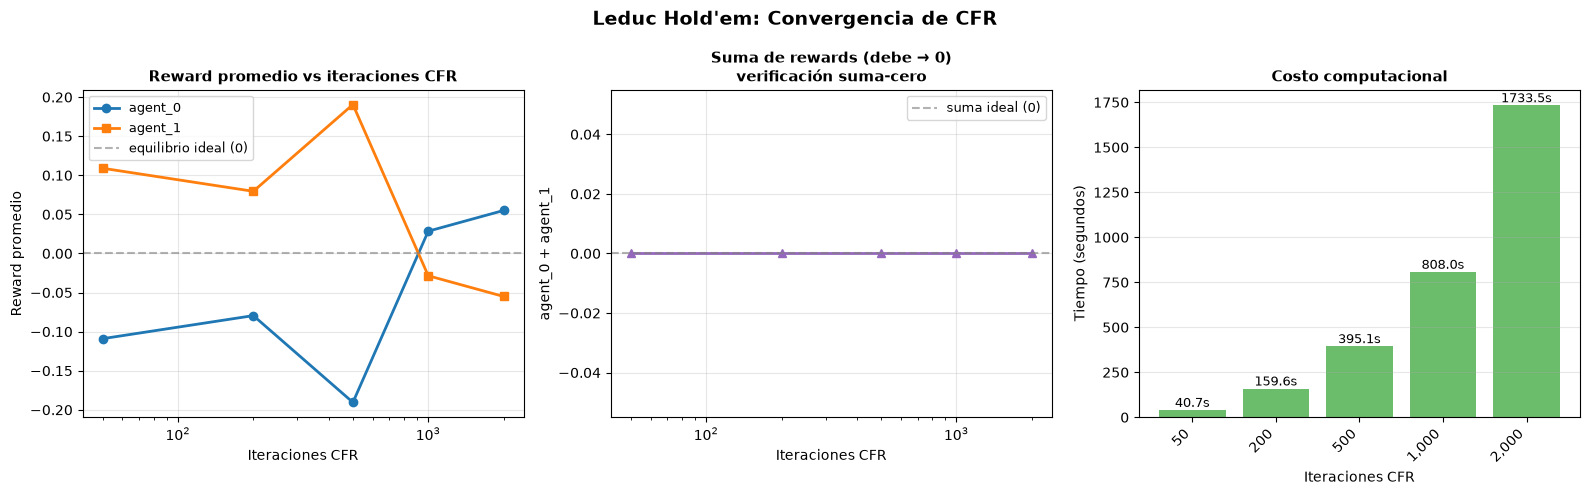


Con 2,000 iteraciones:
  agent_0 = +0.0550  |  agent_1 = -0.0550
  Suma total = +0.000000  (idealmente 0)


In [6]:
# Convergencia de CFR en Leduc Hold'em
import matplotlib.pyplot as plt
import numpy as np
from time import perf_counter

print("Entrenando CFR con diferentes iteraciones para observar convergencia...\n")

training_iterations = [50, 200, 500, 1_000, 2_000]
eval_games = 1_000
convergence_results = []

for n_iter in training_iterations:
    print(f"Entrenando con {n_iter:,} iteraciones...")
    start = perf_counter()

    train_game = Leduc(render_mode='')
    train_game.reset()
    agents = {
        train_game.agents[0]: CounterFactualRegret(game=train_game, agent=train_game.agents[0]),
        train_game.agents[1]: CounterFactualRegret(game=train_game, agent=train_game.agents[1]),
    }
    for agent in train_game.agents:
        agents[agent].train(n_iter)
    train_time = perf_counter() - start

    eval_game = Leduc(render_mode='')
    cum_rewards = {agent: 0.0 for agent in eval_game.agents}
    for _ in range(eval_games):
        rewards = play_game(eval_game, agents)
        for agent, reward in rewards.items():
            cum_rewards[agent] += reward

    avg_rewards = {agent: cum_rewards[agent] / eval_games for agent in eval_game.agents}
    sum_rewards = sum(avg_rewards.values())
    convergence_results.append({
        'n_iter': n_iter,
        'agent_0': avg_rewards[eval_game.agents[0]],
        'agent_1': avg_rewards[eval_game.agents[1]],
        'sum': sum_rewards,
        'train_time': train_time,
    })
    print(
        f"  agent_0={avg_rewards[eval_game.agents[0]]:+.4f}  "
        f"agent_1={avg_rewards[eval_game.agents[1]]:+.4f}  "
        f"suma={sum_rewards:+.4f}  t={train_time:.2f}s"
    )

# Visualización
iters  = [r['n_iter']    for r in convergence_results]
vals_0 = [r['agent_0']  for r in convergence_results]
vals_1 = [r['agent_1']  for r in convergence_results]
sums   = [r['sum']       for r in convergence_results]
times  = [r['train_time'] for r in convergence_results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: reward promedio vs iteraciones
ax1 = axes[0]
ax1.plot(iters, vals_0, marker='o', linewidth=2, label='agent_0', color='tab:blue')
ax1.plot(iters, vals_1, marker='s', linewidth=2, label='agent_1', color='tab:orange')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.6, label='equilibrio ideal (0)')
ax1.set_xscale('log')
ax1.set_title('Reward promedio vs iteraciones CFR', fontsize=11, fontweight='bold')
ax1.set_xlabel('Iteraciones CFR', fontsize=10)
ax1.set_ylabel('Reward promedio', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: suma de rewards (debe ser 0 en juego de suma cero)
ax2 = axes[1]
ax2.plot(iters, sums, marker='^', linewidth=2, color='tab:purple')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.6, label='suma ideal (0)')
ax2.set_xscale('log')
ax2.set_title('Suma de rewards (debe → 0)\nverificación suma-cero', fontsize=11, fontweight='bold')
ax2.set_xlabel('Iteraciones CFR', fontsize=10)
ax2.set_ylabel('agent_0 + agent_1', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: tiempo de entrenamiento
ax3 = axes[2]
bars = ax3.bar(range(len(iters)), times, color='tab:green', alpha=0.7)
ax3.set_xticks(range(len(iters)))
ax3.set_xticklabels([f'{n:,}' for n in iters], rotation=45, ha='right')
ax3.set_title('Costo computacional', fontsize=11, fontweight='bold')
ax3.set_xlabel('Iteraciones CFR', fontsize=10)
ax3.set_ylabel('Tiempo (segundos)', fontsize=10)
ax3.grid(True, axis='y', alpha=0.3)
for bar, t in zip(bars, times):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{t:.1f}s', ha='center', va='bottom', fontsize=9)

fig.suptitle("Leduc Hold'em: Convergencia de CFR", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

final = convergence_results[-1]
print(f"\nCon {final['n_iter']:,} iteraciones:")
print(f"  agent_0 = {final['agent_0']:+.4f}  |  agent_1 = {final['agent_1']:+.4f}")
print(f"  Suma total = {final['sum']:+.6f}  (idealmente 0)")